<a href="https://colab.research.google.com/github/peulearning/notebooks_tcc/blob/main/C%C3%B3pia_de_Escala_Cinza_Archictecture_MobileNetV2_2_Classes_Modify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo / Sistema de Classificação de Feridas - MobileNetV2

### Bacharelado em Sistemas de Informações

#### IFNMG Campus Januária

---

### Orientador: Drº Mr. Prof. Felipe Augusto Oliveira Mota  
### Co-orientador(a) : Mr. Profª Suzana Vieira Mota
### Discente: Pedro Henrique Araújo Mattos Ribeiro  

---

## Estudo da Implementação do Modelo MobileNetV2
### Classificação de Imagens de Feridas e Lesões Cutâneas

# Classificação de Feridas Cutâneas com MobileNetV2

Neste notebook, iremos aplicar o modelo **MobileNetV2**, uma rede neural convolucional leve desenvolvida pelo **Google**, para a **classificação de feridas cutâneas**.  

O objetivo é:
- Observar o desempenho comparado à rede CNN anterior.

---

## O que é o MobileNetV2?

O **MobileNetV2** é uma arquitetura eficiente para **visão computacional em dispositivos móveis e embarcados**.  
Sua estrutura se baseia em dois conceitos principais:

- **Convoluções separáveis em profundidade (Depthwise Separable Convolutions)**: aplicam um filtro por canal, reduzindo drasticamente o número de parâmetros.
- **Blocos Inverted Residual com Linear Bottlenecks**: permitem que a rede aprenda representações compactas, mantendo alta precisão.

A vantagem do MobileNetV2 é seu **baixo custo computacional** e **boa acurácia**, ideal para aplicações em **IoT médica** e **educação em enfermagem**.

---

## Estrutura geral do notebook

1. Importação das bibliotecas;
2. Preparação dos datasets (treino, validação e teste);
3. Configuração dos `ImageDataGenerator`;
4. Carregamento do MobileNetV2 pré-treinado;
5. Criação da nova cabeça de classificação;
6. Treinamento e Fine-tuning;
7. Avaliação e visualização dos resultados.


# - 1. Importações Iniciais

In [73]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow versão:", tf.__version__)


TensorFlow versão: 2.20.0


In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [75]:
import tensorflow as tf

def convert_to_grayscale_3_channels(image, label):
    # Converte para escala de cinza (1 canal)
    image = tf.image.rgb_to_grayscale(image)
    # Replica o canal de cinza 3 vezes para voltar a ter 3 canais
    image = tf.image.grayscale_to_rgb(image)
    return image, label

# - 2. Célula para limpar Imagens do Drive

In [76]:
import os
import shutil


#Esta célula foi criada com intuito de apagar todas as imagens e diretórios para executar o modelo quantas vezes serem necessárias
# Lista de pastas a serem removidas
pastas_para_remover = [
    "/content/drive/MyDrive/data_wounds",
    "/content/drive/MyDrive/data_big",
    "/content/drive/MyDrive/images_ready",
    "/content/drive/MyDrive/data_split",
    "/content/drive/MyDrive/data_split_reduzido"
]

print("Iniciando a remoção das pastas...")

for pasta in pastas_para_remover:
    if os.path.exists(pasta):
        try:
            shutil.rmtree(pasta)
            print(f"Pasta '{pasta}' removida com sucesso.")
        except OSError as e:
            print(f"Erro ao remover a pasta '{pasta}': {e}")
    else:
        print(f"Pasta '{pasta}' não encontrada.")

print("✅ Limpeza concluída.")

Iniciando a remoção das pastas...
Pasta '/content/drive/MyDrive/data_wounds' removida com sucesso.
Pasta '/content/drive/MyDrive/data_big' não encontrada.
Pasta '/content/drive/MyDrive/images_ready' removida com sucesso.
Pasta '/content/drive/MyDrive/data_split' removida com sucesso.
Pasta '/content/drive/MyDrive/data_split_reduzido' não encontrada.
✅ Limpeza concluída.


# - 3. Descompacter o DataSet do artigo ou repositório   https://github.com/uwm-bigdata/wound-classification-using-images-and-locations/tree/main

In [77]:
# Descompactar
import zipfile
import os

# Caminho do arquivo ZIP
caminho_zip = "/content/drive/MyDrive/wound-classification-using-images-and-locations-main.zip"

# Caminho de destino para descompactar
destino = "/content/drive/MyDrive/extraido"

# Cria a pasta de destino se não existir
os.makedirs(destino, exist_ok=True)

# Descompacta o ZIP
with zipfile.ZipFile(caminho_zip, 'r') as zip_ref:
    zip_ref.extractall(destino)

print(f"Arquivos extraídos para: {destino}")

Arquivos extraídos para: /content/drive/MyDrive/extraido


# - 4. Listagem de Pasta do Zip

In [78]:
# Listar somente pastas da estrutura extraída
for root, dirs, files in os.walk(destino):
    level = root.replace(destino, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    for d in dirs:
        sub_indent = ' ' * 4 * (level + 1)
        print(f"{sub_indent}{d}/")

extraido/
    wound-classification-using-images-and-locations-main/
    wound-classification-using-images-and-locations-main/
        dataset/
        dataset/
            Test/
            Train/
            Test/
                Test/
                __MACOSX/
                Test/
                    BG/
                    D/
                    N/
                    P/
                    S/
                    V/
                    BG/
                    D/
                    N/
                    P/
                    S/
                    V/
                __MACOSX/
                    Test/
                    Test/
                        BG/
                        D/
                        N/
                        P/
                        S/
                        V/
                        BG/
                        D/
                        N/
                        P/
                        S/
                        V/
            Train/
              

# - 5. Unindo todas as imagens para facilitar

In [79]:
# Salvar imagen e m um data set organizado para trabalhar melhor /content/base_de_dados_feridas
import os
import shutil

# Caminhos
caminho_base = "/content/drive/MyDrive/data_wounds"
os.makedirs(caminho_base, exist_ok=True)

# Mapeamento das siglas para nomes completos
sigla_para_nome = {
    'D': 'diabetic',
    'N': 'normal',
    'P': 'pressure',
    'S': 'sirurgical',
    'V': 'venous',
    'BG':'background'
}

# Caminhos das pastas de origem
train_dir = "/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Train/Train"
test_dir = "/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Test/Test"

# Função para copiar as imagens
def copiar_imagens(origem, destino_base, renomear_pasta=False):
    for nome_pasta in os.listdir(origem):
        caminho_origem = os.path.join(origem, nome_pasta)

        if not os.path.isdir(caminho_origem):
            continue

        # Renomeia caso seja pasta de sigla
        if renomear_pasta and nome_pasta in sigla_para_nome:
            nome_final = sigla_para_nome[nome_pasta]
        else:
            nome_final = nome_pasta

        caminho_destino = os.path.join(destino_base, nome_final)
        os.makedirs(caminho_destino, exist_ok=True)

        # Copia os arquivos de imagem
        for nome_arquivo in os.listdir(caminho_origem):
            origem_arquivo = os.path.join(caminho_origem, nome_arquivo)
            destino_arquivo = os.path.join(caminho_destino, nome_arquivo)

            if os.path.isfile(origem_arquivo):
                shutil.copy2(origem_arquivo, destino_arquivo)

# Copiar imagens de Train (sem renomear)
copiar_imagens(train_dir, caminho_base)

# Copiar imagens de Test (renomeando siglas)
copiar_imagens(test_dir, caminho_base, renomear_pasta=True)

print("Imagens unificadas em:", caminho_base)

Imagens unificadas em: /content/drive/MyDrive/data_wounds


In [80]:
import shutil
import os

# List of folders to remove from /content/drive/MyDrive/data_wounds
folders_to_remove = [
    "/content/drive/MyDrive/data_wounds/sirurgical",
    "/content/drive/MyDrive/data_wounds/venous",
    "/content/drive/MyDrive/data_wounds/normal",
    "/content/drive/MyDrive/data_wounds/background",
]

print("Iniciando a remoção das pastas indesejadas...")

for pasta in folders_to_remove:
    if os.path.exists(pasta):
        try:
            shutil.rmtree(pasta)
            print(f"Pasta '{os.path.basename(pasta)}' removida com sucesso.")
        except OSError as e:
            print(f"Erro ao remover a pasta '{os.path.basename(pasta)}': {e}")
    else:
        print(f"Pasta '{os.path.basename(pasta)}' não encontrada.")

print("✅ Limpeza concluída.")

Iniciando a remoção das pastas indesejadas...
Pasta 'sirurgical' removida com sucesso.
Pasta 'venous' removida com sucesso.
Pasta 'normal' removida com sucesso.
Pasta 'background' removida com sucesso.
✅ Limpeza concluída.


# - 6. Quantidade de imagens por diretórios

In [81]:
# @title
# contar imagem na pasta da base de dados
import os

# Caminho para a pasta base
base_dir = "/content/drive/MyDrive/data_wounds"

# Inicializar o contador total de imagens
total_images = 0

# Iterar pelas pastas dentro da pasta base
for folder_name in os.listdir(base_dir):
  folder_path = os.path.join(base_dir, folder_name)
  if os.path.isdir(folder_path):  # Verificar se é uma pasta
    image_count = 0
    for filename in os.listdir(folder_path):
      if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')): # Inclui mais extensões de imagem
        image_count += 1
    total_images += image_count
    print(f"Pasta '{folder_name}': {image_count} imagens")

print(f"Total de imagens no dataset: {total_images}")

Pasta 'diabetic': 185 imagens
Pasta 'pressure': 134 imagens
Total de imagens no dataset: 319


# - 7. Balanceamento de Imagens

In [82]:
# import os
# import shutil
# #from keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
# import tensorflow as tf
# from keras.utils import load_img, img_to_array, array_to_img #updated imports
# import numpy as np
# from tqdm import tqdm
# from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import the ImageDataGenerator class


# # Configurações
# CAMINHO_ORIGEM = '/content/drive/MyDrive/data_wounds'
# CAMINHO_DESTINO = '/content/drive/MyDrive/data_big'
# NUM_IMAGENS_DESEJADAS = 900  # Você pode mudar esse valor para 900, etc.
# TAMANHO_IMAGEM = (224, 224)  # Você também pode mudar aqui

# # Aumentos suaves (para manter características das feridas)
# datagen = ImageDataGenerator(
#     rotation_range=10,
#     width_shift_range=0.02,
#     height_shift_range=0.02,
#     zoom_range=0.05,
#     brightness_range=[0.9, 1.1],
#     horizontal_flip=True,
#     fill_mode='nearest'
# )

# # Criar pasta de destino do zero
# if os.path.exists(CAMINHO_DESTINO):
#     shutil.rmtree(CAMINHO_DESTINO)
# os.makedirs(CAMINHO_DESTINO, exist_ok=True)

# # Para cada classe
# for classe in os.listdir(CAMINHO_ORIGEM):
#     pasta_origem = os.path.join(CAMINHO_ORIGEM, classe)
#     pasta_destino = os.path.join(CAMINHO_DESTINO, classe)
#     os.makedirs(pasta_destino, exist_ok=True)

#     imagens_existentes = os.listdir(pasta_origem)
#     total_existente = len(imagens_existentes)

#     print(f"\nClasse '{classe}': {total_existente} imagens existentes.")

#     contador = 0
#     pbar = tqdm(total=NUM_IMAGENS_DESEJADAS, desc=f"Gerando para {classe}")

#     # Copiar imagens originais
#     for nome_img in imagens_existentes:
#         caminho_img = os.path.join(pasta_origem, nome_img)
#         shutil.copy(caminho_img, os.path.join(pasta_destino, nome_img))
#         contador += 1
#         pbar.update(1)
#         if contador >= NUM_IMAGENS_DESEJADAS:
#             break

#     # Se ainda não atingiu a quantidade desejada, gerar aumentadas
#     while contador < NUM_IMAGENS_DESEJADAS:
#         for nome_img in imagens_existentes:
#             img_path = os.path.join(pasta_origem, nome_img)
#             img = load_img(img_path, target_size=TAMANHO_IMAGEM)
#             x = img_to_array(img)
#             x = x.reshape((1,) + x.shape)

#             # Gerar apenas uma imagem aumentada por vez
#             for batch in datagen.flow(x, batch_size=1):
#                 img_aumentada = array_to_img(batch[0])
#                 nome_arquivo = f"aumentada_{contador}_{nome_img}"
#                 img_aumentada.save(os.path.join(pasta_destino, nome_arquivo))
#                 contador += 1
#                 pbar.update(1)
#                 break  # Apenas uma imagem por iteração
#             if contador >= NUM_IMAGENS_DESEJADAS:
#                 break
#     pbar.close()

# print("\n✅ Aumento de dados concluído com sucesso!")

# - 8. Contagem de Imagens depois do Balanceamento

In [83]:
# contar imagem na pasta da base de dados

import os

# Caminho para a pasta base
base_dir = "/content/drive/MyDrive/data_wounds"

# Inicializar o contador total de imagens
total_images = 0

# Iterar pelas pastas dentro da pasta base
for folder_name in os.listdir(base_dir):
  folder_path = os.path.join(base_dir, folder_name)
  if os.path.isdir(folder_path):  # Verificar se é uma pasta
    image_count = 0
    for filename in os.listdir(folder_path):
      if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')): # Inclui mais extensões de imagem
        image_count += 1
    total_images += image_count
    print(f"Pasta '{folder_name}': {image_count} imagens")

print(f"Total de imagens no dataset: {total_images}")

Pasta 'diabetic': 185 imagens
Pasta 'pressure': 134 imagens
Total de imagens no dataset: 319


# - 9. Pasta de Saída para Resultados

In [84]:
def combined_grayscale_preprocess(img):
    # 1. img chega como array numpy [0, 255]
    # 2. Converte para cinza (ponderado)
    gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])

    # 3. Replica para 3 canais (H, W, 3)
    gray_3ch = np.stack((gray,)*3, axis=-1)

    # 4. Aplica a normalização específica da MobileNetV2 (escala para [-1, 1])
    return tf.keras.applications.mobilenet_v2.preprocess_input(gray_3ch)

In [85]:
def to_grayscale_3_channels(image):
    # image é um array numpy (H, W, 3)
    # Converte para escala de cinza usando pesos padrão (1 canal)
    grayscale = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140])
    # Expande para (H, W, 1) e replica para (H, W, 3)
    grayscale_3_channels = np.stack((grayscale,)*3, axis=-1)
    return grayscale_3_channels

In [86]:
# import os
# from PIL import Image
# import shutil

# # Caminho da base original
# CAMINHO_ORIGINAL = "/content/drive/MyDrive/data_wounds"
# # Caminho para salvar imagens processadas
# CAMINHO_SAIDA = "/content/drive/MyDrive/images_ready"
# # Tamanho desejado
# TAMANHO = (224, 224)

# # Cria a pasta de saída se não existir
# os.makedirs(CAMINHO_SAIDA, exist_ok=True)

# # Loop pelas classes (pastas)
# for classe in os.listdir(CAMINHO_ORIGINAL):
#     pasta_classe_origem = os.path.join(CAMINHO_ORIGINAL, classe)
#     pasta_classe_saida = os.path.join(CAMINHO_SAIDA, classe)

#     if not os.path.isdir(pasta_classe_origem):
#         continue

#     os.makedirs(pasta_classe_saida, exist_ok=True)

#     # Loop pelas imagens da classe
#     for nome_arquivo in os.listdir(pasta_classe_origem):
#         caminho_imagem = os.path.join(pasta_classe_origem, nome_arquivo)

#         try:
#             img = Image.open(caminho_imagem)

#             # Converter para RGB se não for
#             if img.mode != 'RGB':
#                 img = img.convert('RGB')

#             # Redimensionar
#             img = img.resize(TAMANHO)

#             # Salvar imagem processada
#             caminho_saida = os.path.join(pasta_classe_saida, nome_arquivo)
#             img.save(caminho_saida)

#         except Exception as e:
#             print(f"Erro ao processar {caminho_imagem}: {e}")

import os
from PIL import Image, ImageOps # Importamos o ImageOps
import shutil

CAMINHO_ORIGINAL = "/content/drive/MyDrive/data_wounds"
CAMINHO_SAIDA = "/content/drive/MyDrive/images_ready"
TAMANHO = (224, 224)

os.makedirs(CAMINHO_SAIDA, exist_ok=True)

for classe in os.listdir(CAMINHO_ORIGINAL):
    pasta_classe_origem = os.path.join(CAMINHO_ORIGINAL, classe)
    pasta_classe_saida = os.path.join(CAMINHO_SAIDA, classe)

    if not os.path.isdir(pasta_classe_origem):
        continue

    os.makedirs(pasta_classe_saida, exist_ok=True)

    for nome_arquivo in os.listdir(pasta_classe_origem):
        caminho_imagem = os.path.join(pasta_classe_origem, nome_arquivo)

        try:
            img = Image.open(caminho_imagem)

            # --- APLICAÇÃO DA ESCALA DE CINZA ---
            # 1. Converte para 1 canal (escala de cinza)
            img = img.convert('L')
            # 2. Converte de volta para RGB (isso replica o canal único em 3 canais R=G=B)
            img = img.convert('RGB')

            # --- A MÁGICA ACONTECE AQUI ---
            # Mantemos o seu redimensionamento com pad (bordas pretas)
            img_processada = ImageOps.pad(img, TAMANHO, color=(0, 0, 0))

            caminho_saida = os.path.join(pasta_classe_saida, nome_arquivo)
            img_processada.save(caminho_saida)

        except Exception as e:
            print(f"Erro ao processar {caminho_imagem}: {e}")

# - 10. Separando as Pastas Treinamento / Validação / Teste

In [87]:
import os
import shutil
import random

# Caminho do dataset original
origem = "/content/drive/MyDrive/images_ready"

# Novo caminho para os dados divididos
destino_base = "/content/drive/MyDrive/data_split"

# Proporções
train_split = 0.7
val_split = 0.15
test_split = 0.15

# Garante que os diretórios existem
os.makedirs(destino_base, exist_ok=True)
for split in ['train', 'val', 'test']:
    for classe in os.listdir(origem):
        os.makedirs(os.path.join(destino_base, split, classe), exist_ok=True)

# Loop pelas classes
for classe in os.listdir(origem):
    caminho_classe = os.path.join(origem, classe)
    imagens = os.listdir(caminho_classe)
    random.shuffle(imagens)

    total = len(imagens)
    n_train = int(train_split * total)
    n_val = int(val_split * total)

    train_imgs = imagens[:n_train]
    val_imgs = imagens[n_train:n_train + n_val]
    test_imgs = imagens[n_train + n_val:]

    for nome_img in train_imgs:
        shutil.copy(os.path.join(caminho_classe, nome_img), os.path.join(destino_base, 'train', classe))

    for nome_img in val_imgs:
        shutil.copy(os.path.join(caminho_classe, nome_img), os.path.join(destino_base, 'val', classe))

    for nome_img in test_imgs:
        shutil.copy(os.path.join(caminho_classe, nome_img), os.path.join(destino_base, 'test', classe))

print("✅ Imagens separadas em treino, validação e teste!")

✅ Imagens separadas em treino, validação e teste!


# - 11. Gerador de Dados de Imagem

In [88]:
def grayscale_3_channels_preprocess(img):
    """
    Garante que a imagem lida pelo Keras seja convertida para cinza
    e replicada em 3 canais antes de entrar no modelo.
    """
    import tensorflow as tf
    # img aqui é um array numpy (224, 224, 3)
    # Converte para cinza (1 canal)
    gray = tf.image.rgb_to_grayscale(img)
    # Replica para 3 canais
    gray_3ch = tf.image.grayscale_to_rgb(gray)
    return gray_3ch.numpy()

In [89]:
directory_train = '/content/drive/MyDrive/data_split/train'
directory_val = '/content/drive/MyDrive/data_split/val'

# Exemplo de onde aplicar:
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory_train,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary' # ou 'categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory_val,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary'
)

# APLICAÇÃO DA ESCALA DE CINZA AQUI:
train_ds = train_ds.map(convert_to_grayscale_3_channels)
val_ds = val_ds.map(convert_to_grayscale_3_channels)
# Repita para o test_ds se houver

Found 222 files belonging to 2 classes.
Found 47 files belonging to 2 classes.


In [90]:
# Gerador para treinamento (com augmentação)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # Import preprocess_input

# Define a combined preprocessing function
def combined_preprocessing_function(img):
    # 1. Converte para Cinza (Luminância)
    # img é (H, W, 3) -> usamos pesos padrão ITU-R 601-2 luma transform
    gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])

    # 2. Replica para 3 canais (H, W, 3)
    gray_3ch = np.stack((gray,)*3, axis=-1)

    # 3. Pre-processamento específico da MobileNetV2 (Normalização para [-1, 1])
    return tf.keras.applications.mobilenet_v2.preprocess_input(gray_3ch)

train_datagen = ImageDataGenerator(
    preprocessing_function=combined_preprocessing_function, # Usa a função combinada
    rotation_range=20,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Gerador para validação e teste (sem augmentação)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=combined_preprocessing_function # Usa a função combinada para validação/teste também
)

train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/data_split/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    "/content/drive/MyDrive/data_split/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    "/content/drive/MyDrive/data_split/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 222 images belonging to 2 classes.
Found 47 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


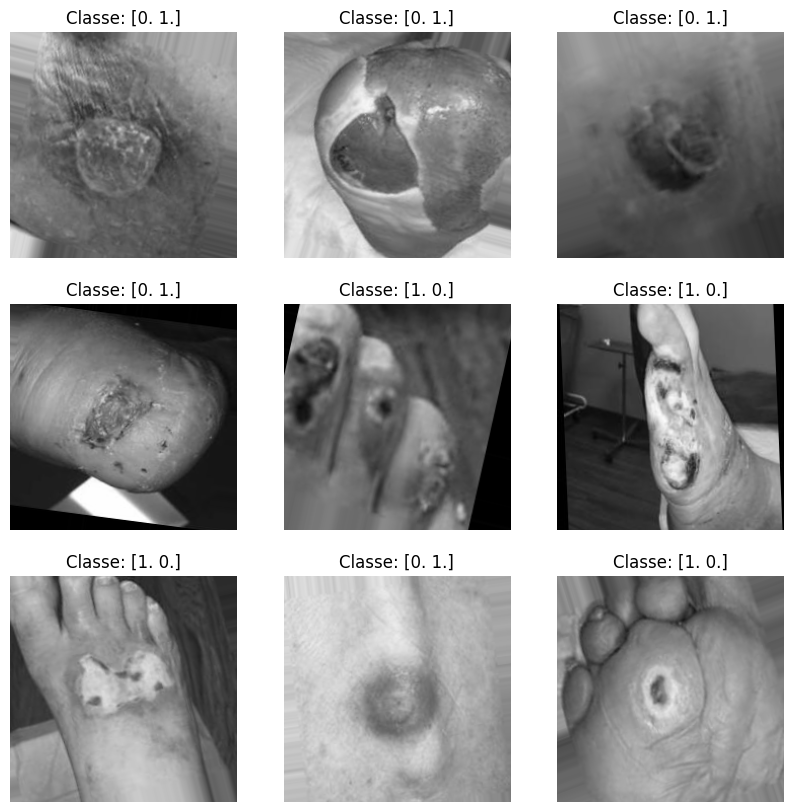

In [91]:
# CÉLULA DE VERIFICAÇÃO VISUAL
import matplotlib.pyplot as plt

# Pega um lote do gerador de treino
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    # Se estiver usando preprocess_input da MobileNetV2,
    # precisamos "des-normalizar" para exibir corretamente
    img_display = images[i]
    if img_display.min() < 0: # Se estiver no range [-1, 1]
        img_display = (img_display + 1) / 2.0

    plt.imshow(img_display)
    plt.title(f"Classe: {labels[i]}")
    plt.axis("off")
plt.show()

In [92]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
])

# Aplique o augmentation e depois garanta a escala de cinza novamente
# (embora o map anterior já tenha resolvido para o treino)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# - 12. Rede Convolucional / MobileNetV2

In [93]:
# Carregar base pré-treinada
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Etapa 1: congelar a base

In [94]:
# Nova cabeça de classificação
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(train_generator.num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [95]:
# Compilar com LR menor
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [96]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)
]

# ===== Fase 1: Treinar só a cabeça =====
print("\n🔹 Fase 1: Treinando apenas as camadas densas...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)

# ===== Fase 2: Fine-tuning =====
print("\n🔹 Fase 2: Liberando parte das camadas da base...")

base_model.trainable = True
for layer in base_model.layers[:-30]:  # congela tudo, exceto as 30 últimas
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=callbacks
)



🔹 Fase 1: Treinando apenas as camadas densas...
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.5360 - loss: 0.9600 - val_accuracy: 0.5319 - val_loss: 0.8497 - learning_rate: 1.0000e-04
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.5270 - loss: 1.0024 - val_accuracy: 0.5957 - val_loss: 0.8319 - learning_rate: 1.0000e-04
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.5811 - loss: 0.8516 - val_accuracy: 0.5745 - val_loss: 0.7297 - learning_rate: 1.0000e-04
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.6036 - loss: 0.7419 - val_accuracy: 0.5319 - val_loss: 0.6876 - learning_rate: 1.0000e-04
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6532 - loss: 0.6657 - val_accuracy: 0.6383 - val_loss: 0.7117 - learning_rate: 1.0000e-04
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7072 - loss: 0.6158 - val_accuracy: 0.6383 - val_loss: 0.7295 - learning_rate: 1.0000e-04
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7200 - loss: 0.5976
Acurácia de teste: 0.7200


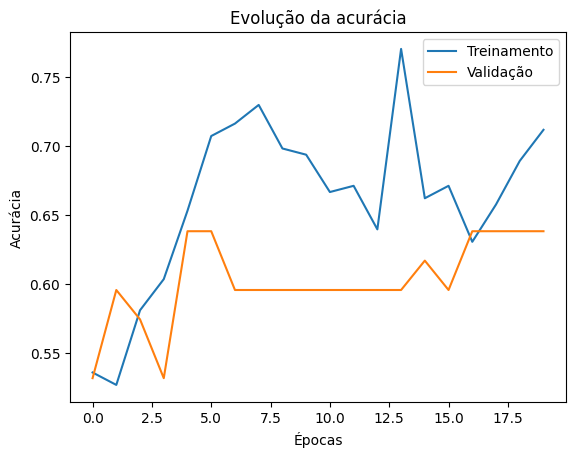

In [97]:
# Avaliação no conjunto de teste
test_loss, test_acc = model.evaluate(test_generator)
print(f"Acurácia de teste: {test_acc:.4f}")

# Curvas de aprendizado
plt.plot(history.history['accuracy'] + fine_history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'] + fine_history.history['val_accuracy'], label='Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.title('Evolução da acurácia')
plt.show()


In [98]:
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,803,464 (22.14 MB)

 Trainable params: 1,690,626 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,381,254 (12.90 MB)

# - 13. Métricas do Modelo

In [99]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Obter as previsões do modelo no conjunto de teste
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Obter os rótulos verdadeiros do conjunto de teste
y_true = test_generator.classes

# Obter os nomes das classes
class_names = list(test_generator.class_indices.keys())

# Gerar a Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
print("\nMatriz de Confusão:")
print(cm)

# Gerar o Relatório de Classificação
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nRelatório de Classificação:")
print(report)

1/2 ━━━━━━━━━━━━━━━━━━━━ 3s 4s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step

Matriz de Confusão:
[[26  3]
 [11 10]]

Relatório de Classificação:
              precision    recall  f1-score   support

    diabetic       0.70      0.90      0.79        29
    pressure       0.77      0.48      0.59        21

    accuracy                           0.72        50
   macro avg       0.74      0.69      0.69        50
weighted avg       0.73      0.72      0.70        50



## Visualização da Matriz de Confusão

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 649ms/step


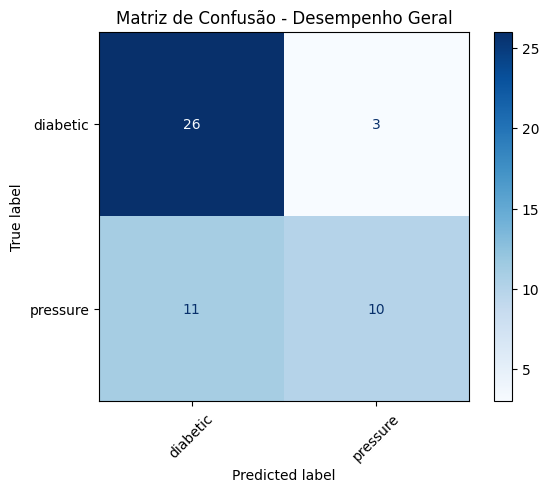


📊 Relatório de Classificação:

              precision    recall  f1-score   support

    diabetic       0.70      0.90      0.79        29
    pressure       0.77      0.48      0.59        21

    accuracy                           0.72        50
   macro avg       0.74      0.69      0.69        50
weighted avg       0.73      0.72      0.70        50


👁️ Extraindo imagens classificadas incorretamente para validação da hipótese...



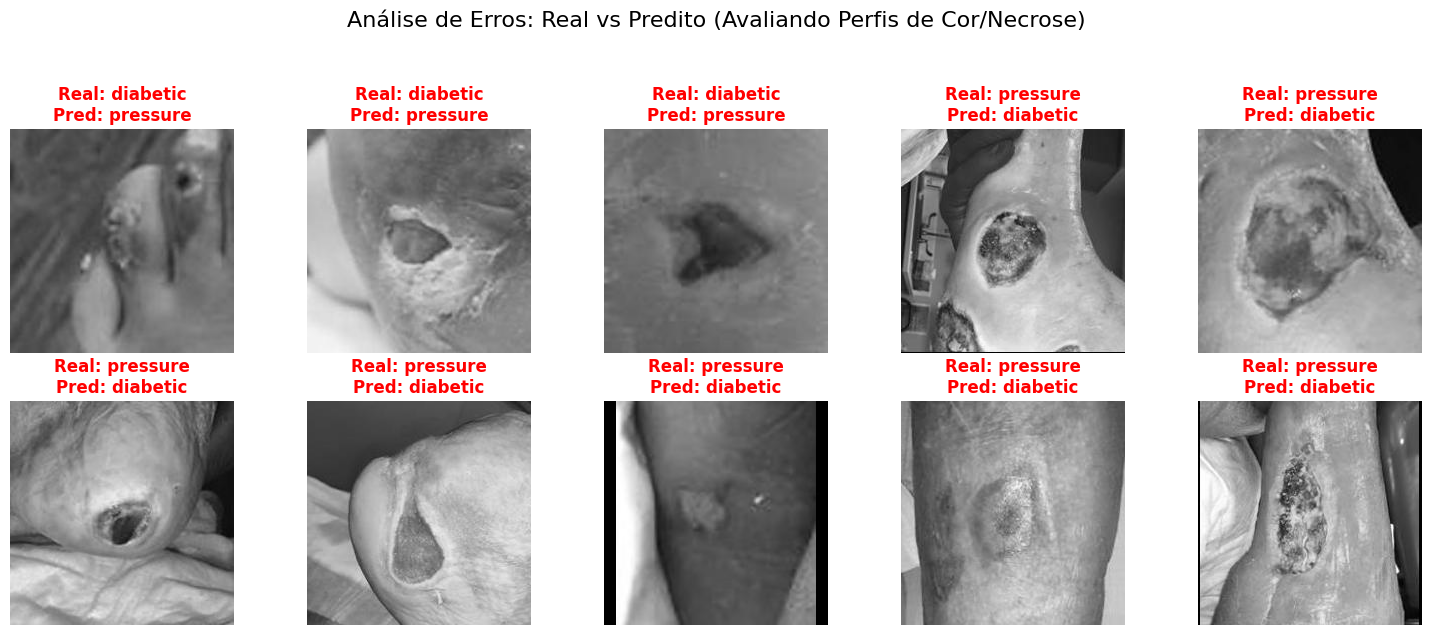

In [100]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. PREDIÇÕES E AVALIAÇÃO GLOBAL
# ==========================================
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator) # Corrected variable name from 'modelo' to 'model'
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(test_generator.class_indices.keys())

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Desempenho Geral")
plt.xticks(rotation=45)
plt.savefig("matriz_confusao.png", bbox_inches='tight') # Salva a imagem para o TCC
plt.show()

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\n📊 Relatório de Classificação:\n")
print(report)

# ==========================================
# 2. ANÁLISE A OLHO NU (Filtro de Erros)
# ==========================================
print("\n👁️ Extraindo imagens classificadas incorretamente para validação da hipótese...\n")

# Encontrar os índices onde o modelo errou
erros_indices = np.where(y_pred != y_true)[0]

if len(erros_indices) == 0:
    print("O modelo acertou todas as predições no conjunto de teste!")
else:
    # Pegar até 10 erros para visualizar
    num_erros_mostrar = min(10, len(erros_indices))
    indices_para_mostrar = erros_indices[:num_erros_mostrar]

    plt.figure(figsize=(15, 6))
    plt.suptitle("Análise de Erros: Real vs Predito (Avaliando Perfis de Cor/Necrose)", fontsize=16, y=1.05)

    # Como test_generator pode não dar acesso direto à imagem por índice facilmente,
    # vamos buscar os caminhos dos arquivos de teste que falharam
    filepaths = test_generator.filepaths

    for i, idx in enumerate(indices_para_mostrar):
        plt.subplot(2, 5, i + 1)

        # Carrega a imagem original que o modelo errou
        img_path = filepaths[idx]
        img = plt.imread(img_path)
        plt.imshow(img)

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        plt.title(f"Real: {true_label}\nPred: {pred_label}", color="red", fontweight='bold')
        plt.axis("off")

    plt.tight_layout()
    plt.savefig("analise_erros_visuais.png", bbox_inches='tight') # Salva a imagem para o TCC
    plt.show()

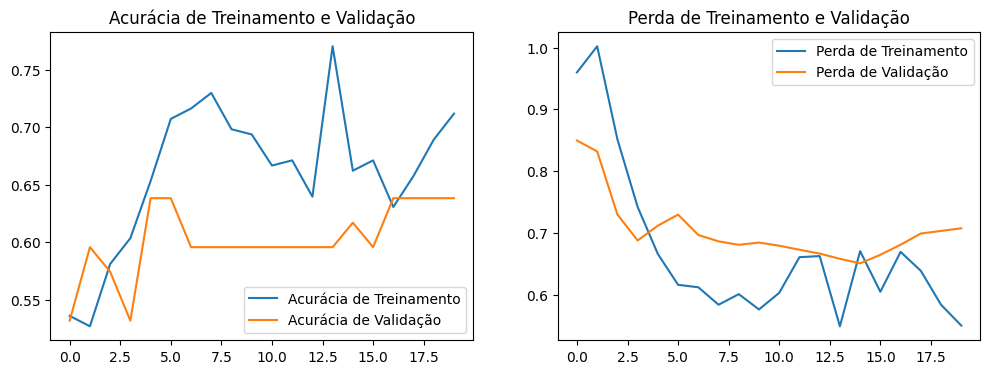

In [101]:
import matplotlib.pyplot as plt

# Concatenar os históricos de treinamento
# Para acurácia
acc = history.history['accuracy'] + fine_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_history.history['val_accuracy']

# Para perda
loss = history.history['loss'] + fine_history.history['loss']
val_loss = history.history['val_loss'] + fine_history.history['val_loss']

epochs_range = range(len(acc))

# Plotar Acurácia
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Acurácia de Treinamento')
plt.plot(epochs_range, val_acc, label='Acurácia de Validação')
plt.legend(loc='lower right')
plt.title('Acurácia de Treinamento e Validação')

# Plotar Perda
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Perda de Treinamento')
plt.plot(epochs_range, val_loss, label='Perda de Validação')
plt.legend(loc='upper right')
plt.title('Perda de Treinamento e Validação')
plt.show()

In [102]:
#Quero Gerar a curva AUC e ROC

/tmp/ipykernel_23099/2543273635.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes) # Get distinct colors for each class


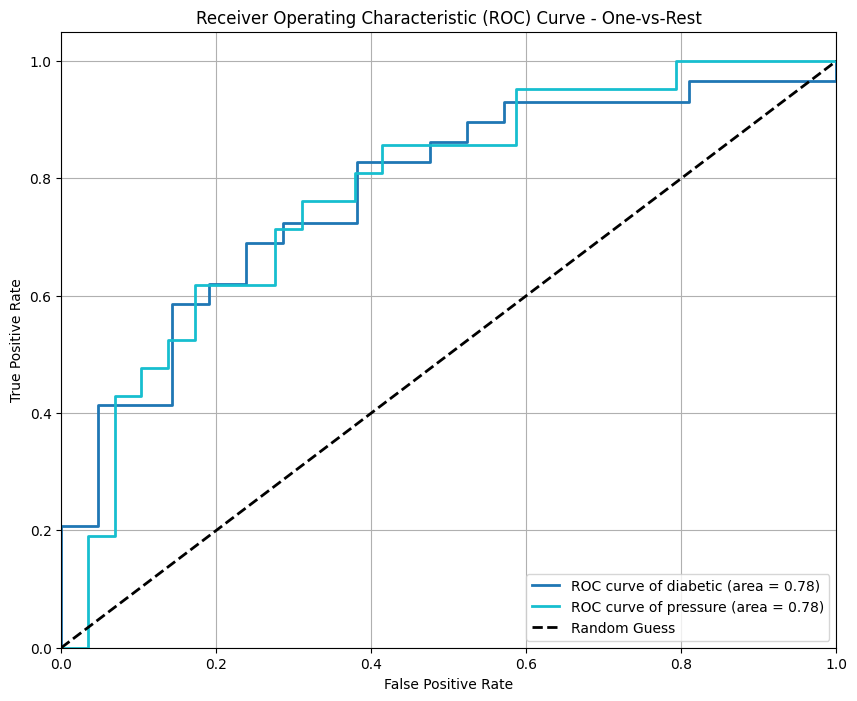

AUC Scores per class:
  diabetic: 0.7767
  pressure: 0.7767


In [103]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_true and y_pred_probs (from previous cells) are available

# Get class names and number of classes
# y_true is already 0 or 1, so we don't need to binarize it into multiple columns
# using label_binarize if we iterate for each class.
n_classes = len(class_names)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # For class i, true labels are 1 where y_true equals i, and 0 otherwise.
    # Predicted probabilities for class i are y_pred_probs[:, i].
    fpr[i], tpr[i], _ = roc_curve(y_true == i, y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes) # Get distinct colors for each class

for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f'ROC curve of {class_name} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("AUC Scores per class:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {roc_auc[i]:.4f}")

# - 14. Salvar o Modelo

In [104]:
# model.save('/content/drive/MyDrive/mobilenetv2_wounds_model_4class.h5')

# - 15. Salvar o Modelo em TFLite / Excel

In [105]:
# import tensorflow as tf
# import pandas as pd
# import os

# # Instalar xlsxwriter se não estiver presente
# try:
#     import xlsxwriter
# except ImportError:
#     %pip install xlsxwriter
#     import xlsxwriter

# # Caminho para salvar o modelo TFLite
# tflite_model_path = '/content/drive/MyDrive/mobilenetv2_wounds_model_4class.tflite'

# # Converter o modelo Keras para TensorFlow Lite
# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# tflite_model = converter.convert()

# # Salvar o modelo TFLite
# with open(tflite_model_path, 'wb') as f:
#     f.write(tflite_model)

# print(f"Modelo salvo em TFLite: {tflite_model_path}")

# # --- Salvar resultados em Excel ---

# # Caminho para o arquivo Excel
# excel_output_path = '/content/drive/MyDrive/resultados_classificacao_mobilenetv2_4class.xlsx'

# # Matriz de Confusão para DataFrame
# cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# # Relatório de Classificação para DataFrame
# # Splitting the report string into lines and then processing it
# report_data = []
# lines = report.split('\n')
# # Skip first line (empty), second line (header), and last three lines (accuracy, macro avg, weighted avg)
# for line in lines[2:-5]:
#     if line.strip():
#         parts = line.split()
#         class_name = parts[0]
#         precision = float(parts[1])
#         recall = float(parts[2])
#         f1_score = float(parts[3])
#         support = int(parts[4])
#         report_data.append([class_name, precision, recall, f1_score, support])

# report_df = pd.DataFrame(report_data, columns=['Class', 'Precision', 'Recall', 'F1-Score', 'Support'])

# # Para as linhas de 'accuracy', 'macro avg' e 'weighted avg'
# summary_data = []
# for line in lines[-4:]:
#     if line.strip() and not line.startswith('accuracy'): # Skip accuracy line as it's computed differently sometimes
#         parts = line.split()
#         if parts[0] == 'accuracy': # Special handling for accuracy line if it appears before macro avg
#             value = float(parts[1])
#             summary_data.append(['accuracy', value, '', '', int(parts[2])])
#         else:
#             metric_type = ' '.join(parts[:-4]) # 'macro avg' or 'weighted avg'
#             precision = float(parts[-4])
#             recall = float(parts[-3])
#             f1_score = float(parts[-2])
#             support = int(parts[-1])
#             summary_data.append([metric_type, precision, recall, f1_score, support])

# summary_df = pd.DataFrame(summary_data, columns=['Class', 'Precision', 'Recall', 'F1-Score', 'Support'])

# # Salvar em um arquivo Excel com múltiplas abas
# with pd.ExcelWriter(excel_output_path, engine='xlsxwriter') as writer:
#     cm_df.to_excel(writer, sheet_name='Confusion Matrix')
#     report_df.to_excel(writer, sheet_name='Classification Report', index=False)
#     summary_df.to_excel(writer, sheet_name='Summary Metrics', index=False)

# print(f"Resultados da classificação salvos em Excel: {excel_output_path}")

# 16 - Avaliação Manual

In [106]:
# import pandas as pd

# # 1. Extrair os caminhos dos arquivos e os rótulos
# # O test_generator guarda os caminhos em .filenames
# caminhos = test_generator.filenames
# # Você já tem y_true e y_pred calculados na célula anterior

# # 2. Criar o DataFrame com os resultados
# df_resultados = pd.DataFrame({
#     'arquivo': caminhos,
#     'real': y_true,
#     'predito': y_pred
# })

# # 3. Mapear os números para os nomes das classes (usando o class_names que você já definiu)
# mapeamento = {i: nome for i, nome in enumerate(class_names)}
# df_resultados['real'] = df_resultados['real'].map(mapeamento)
# df_resultados['predito'] = df_resultados['predito'].map(mapeamento)

# # 4. Filtrar apenas onde o modelo errou
# df_erros = df_resultados[df_resultados['real'] != df_resultados['predito']].copy()

# # 5. Adicionar a coluna para sua análise visual
# df_erros['perfil_visual'] = "" # Você vai preencher isso no Excel/Sheets

# # 6. Salvar no Google Drive
# caminho_csv = '/content/drive/MyDrive/HealScan_Analise_Errosws_Mobile.csv'
# df_erros.to_csv(caminho_csv, index=False)

# print(f"✅ Sucesso! Arquivo gerado com {len(df_erros)} erros.")
# print(f"📂 Local: {caminho_csv}")

✅ Sucesso! Arquivo gerado com 14 erros.
📂 Local: /content/drive/MyDrive/HealScan_Analise_Errosws_Mobile.csv


🔍 Foram encontrados 14 erros. Gerando visualização...


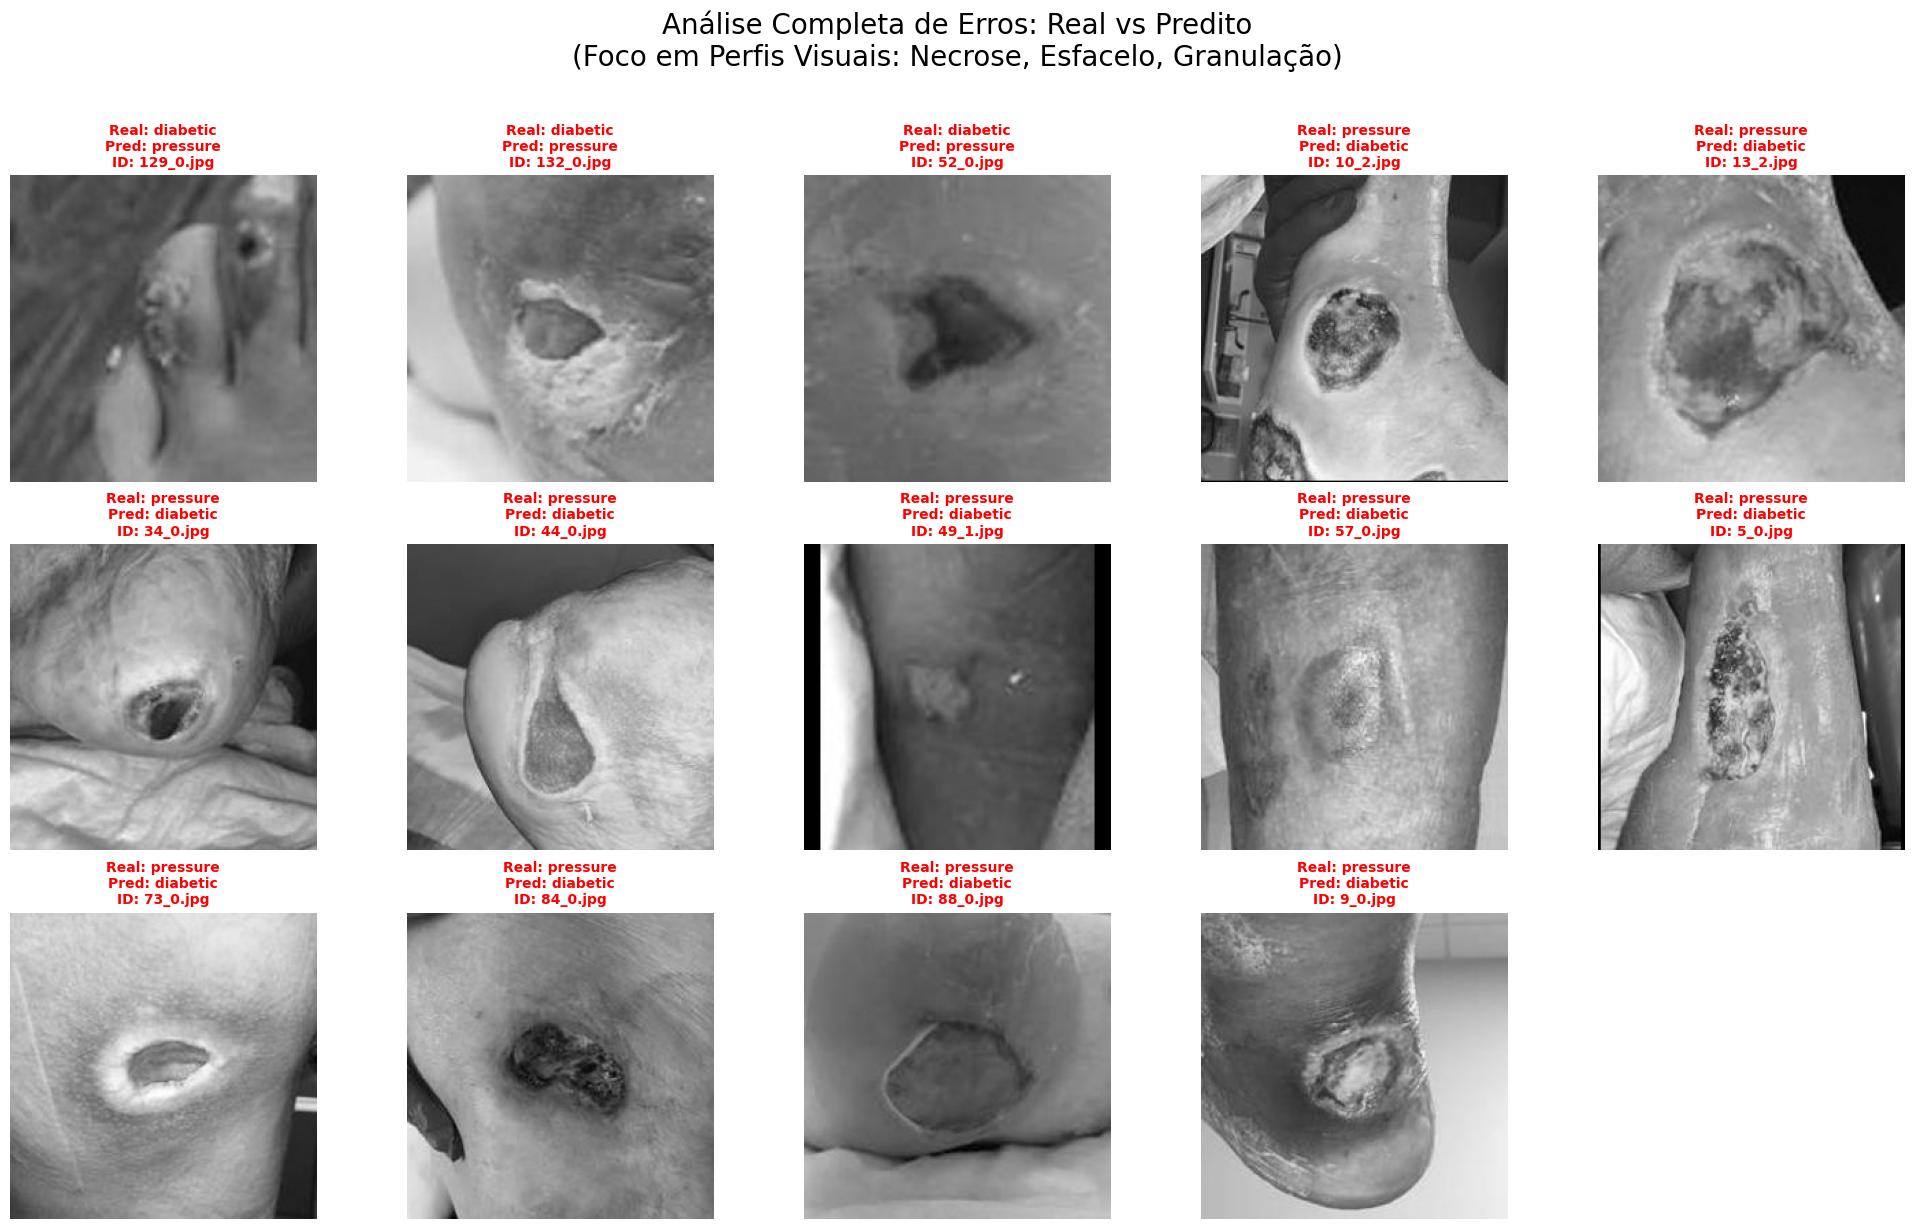

In [107]:
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. Identificar todos os índices de erro
erros_indices = np.where(y_pred != y_true)[0]
total_erros = len(erros_indices)

if total_erros == 0:
    print("✅ O modelo não cometeu erros no conjunto de teste!")
else:
    print(f"🔍 Foram encontrados {total_erros} erros. Gerando visualização...")

    # Configuração da grade (grid) de visualização
    # Vamos exibir 5 imagens por linha
    cols = 5
    rows = math.ceil(total_erros / cols)

    plt.figure(figsize=(20, 4 * rows))
    plt.suptitle("Análise Completa de Erros: Real vs Predito\n(Foco em Perfis Visuais: Necrose, Esfacelo, Granulação)",
                 fontsize=20, y=1.02)

    filepaths = test_generator.filepaths

    for i, idx in enumerate(erros_indices):
        plt.subplot(rows, cols, i + 1)

        # Carregar imagem
        img_path = filepaths[idx]
        img = plt.imread(img_path)
        plt.imshow(img)

        # Rótulos
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        # Título com as informações do erro
        # Pegamos o nome do arquivo para facilitar se você precisar buscar no Drive
        nome_arquivo = img_path.split('/')[-1]

        plt.title(f"Real: {true_label}\nPred: {pred_label}\nID: {nome_arquivo}",
                  color="red", fontsize=10, fontweight='bold')
        plt.axis("off")

    plt.tight_layout()
    # Salva em alta resolução para você poder dar zoom e analisar cada uma
    plt.savefig("galeria_completa_erros.png", bbox_inches='tight', dpi=150)
    plt.show()

Encontrados 14 erros para análise Grad-CAM.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


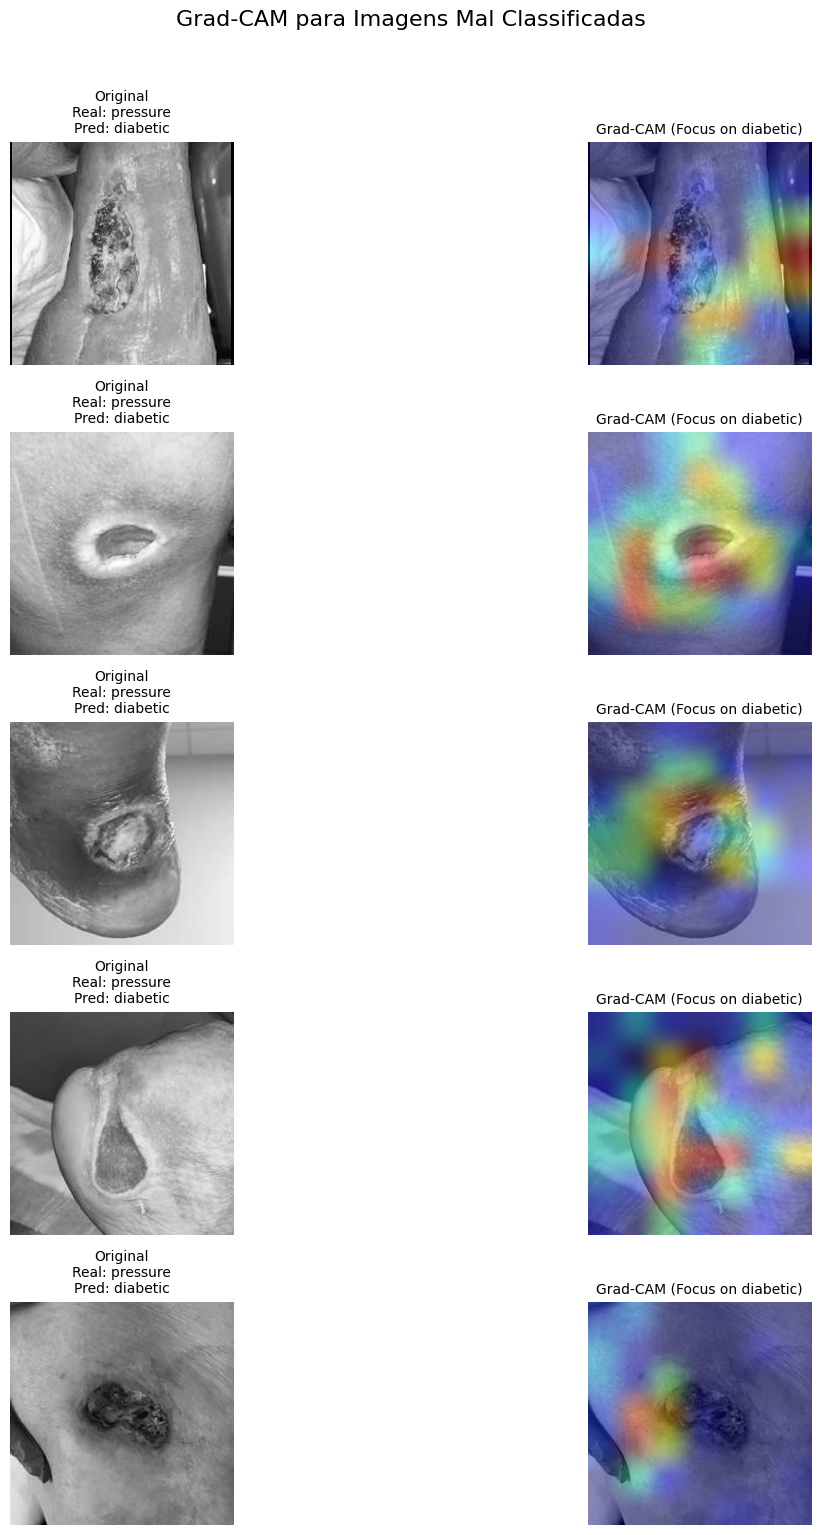

In [114]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Ensure img_array has a batch dimension if it's just (H, W, C)
    if len(img_array.shape) == 3:
        img_array = np.expand_dims(img_array, axis=0)

    # 1. Define a new input for the Grad-CAM model
    # Use img_array.shape[1:] to get (H, W, C) without the batch dimension
    grad_cam_inputs = tf.keras.Input(shape=img_array.shape[1:])

    # 2. Get the base MobileNetV2 layer from the main model
    base_model_layer = model.get_layer('mobilenetv2_1.00_224')

    # 3. Pass the new input through the base model layer (feature extractor)
    # The output of MobileNetV2 with include_top=False is its last conv layer features.
    # Pass training=False to ensure inference mode (e.g., BatchNorm layers behave correctly)
    features_from_base = base_model_layer(grad_cam_inputs, training=False)

    # 4. Reconstruct the classification head of the original model
    # Iterate through the layers of the original model's head (after the base_model_layer)
    # The main 'model' structure is: InputLayer -> mobilenetv2_1.00_224 -> GlobalAveragePooling2D -> Dropout -> Dense -> Dropout -> Dense
    # So, we need to apply layers starting from GlobalAveragePooling2D
    x_head = features_from_base

    # We start from model.layers[2] because index 0 is InputLayer and index 1 is mobilenetv2_1.00_224
    for layer in model.layers[2:]:
        # Apply the layer to x_head, handling Dropout layers in inference mode
        if isinstance(layer, tf.keras.layers.Dropout):
            x_head = layer(x_head, training=False) # Ensure dropout is off for inference
        else:
            x_head = layer(x_head)

    final_preds_from_head = x_head # This is the final prediction tensor

    # 5. Create the Grad-CAM model with the new input and both desired outputs
    grad_model = tf.keras.models.Model(
        inputs=grad_cam_inputs,
        outputs=[features_from_base, final_preds_from_head]
    )

    with tf.GradientTape() as tape:
        # Watch the input tensor for gradients
        img_tensor = tf.cast(img_array, tf.float32)
        tape.watch(img_tensor)

        # Call grad_model with the image tensor.
        # Since grad_cam_inputs was a single Input, passing img_tensor directly is correct.
        last_conv_layer_output, preds = grad_model(img_tensor)

        if pred_index is None:
            # Get the index of the predicted class with highest probability
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Compute gradients of the predicted class with respect to the last conv layer output
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Pool the gradients over all the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0] # Remove batch dimension
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap to be between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image again for display (without MobileNetV2 preprocessing)
    # The image from file is expected to be [0, 255]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img = tf.keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.colormaps["jet"] # Use plt.colormaps instead of cm.get_cmap

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    # Convert original image to float for blending
    img_float = img.astype(np.float32)
    superimposed_img = jet_heatmap * alpha + img_float * (1 - alpha)

    # Normalize to 0-255 and convert back to image
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    # Return as numpy array directly, not an Image object
    return superimposed_img

# --- Main execution part to pick random error images and display Grad-CAM ---

# Assuming 'df_erros', 'test_generator', 'model', 'class_names' are available from previous cells.
# And 'combined_preprocessing_function' (from cell voGjGoPVIiT2) is available.

if 'df_erros' in locals() and not df_erros.empty:
    print(f"Encontrados {len(df_erros)} erros para análise Grad-CAM.")
    # Take a random sample of misclassified images, e.g., 5 images
    num_samples_to_show = min(5, len(df_erros)) # Show up to 5 misclassified images
    sample_erros = df_erros.sample(num_samples_to_show)

    plt.figure(figsize=(15, num_samples_to_show * 3))
    plt.suptitle("Grad-CAM para Imagens Mal Classificadas", fontsize=16, y=1.02)

    for i, (idx, row) in enumerate(sample_erros.iterrows()):
        relative_img_path = row['arquivo'] # e.g., 'diabetic/129_0.jpg'

        # Need to reconstruct the full path from the test_generator directory
        test_dir_base = "/content/drive/MyDrive/data_split/test"
        full_img_path = os.path.join(test_dir_base, relative_img_path)

        # Load and preprocess the image for the model
        img_raw = tf.keras.preprocessing.image.load_img(full_img_path, target_size=(224, 224))
        img_array = tf.keras.preprocessing.image.img_to_array(img_raw)

        # Apply the same preprocessing function used for training/inference
        # This function also includes grayscale conversion and MobileNetV2 preprocessing
        img_preprocessed = combined_preprocessing_function(img_array)

        # Get predicted class (the one the model actually predicted)
        # model.predict expects a batch, so add the batch dimension for prediction
        predictions = model.predict(np.expand_dims(img_preprocessed, axis=0))
        predicted_class_idx = np.argmax(predictions[0])
        predicted_class_name = class_names[predicted_class_idx]

        # Get actual class name
        true_class_name = row['real']

        # Generate Grad-CAM heatmap
        # 'out_relu' is the last convolutional layer in MobileNetV2 base
        # pred_index is passed to focus the heatmap on the class the model predicted (correctly or incorrectly)
        heatmap = make_gradcam_heatmap(img_preprocessed, model, 'out_relu', pred_index=predicted_class_idx)

        # Display results
        plt.subplot(num_samples_to_show, 2, i * 2 + 1)
        plt.imshow(img_raw) # Show original image
        plt.title(f"Original\nReal: {true_class_name}\nPred: {predicted_class_name}", fontsize=10)
        plt.axis("off")

        plt.subplot(num_samples_to_show, 2, i * 2 + 2)
        # Use the numpy array returned by display_gradcam directly
        superimposed_img_np = display_gradcam(full_img_path, heatmap)
        plt.imshow(superimposed_img_np)
        plt.title(f"Grad-CAM (Focus on {predicted_class_name})", fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível carregar 'df_erros' ou o DataFrame está vazio. Verifique se a célula de análise de erros foi executada e se há erros.")

Encontrados 36 acertos para análise Grad-CAM.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


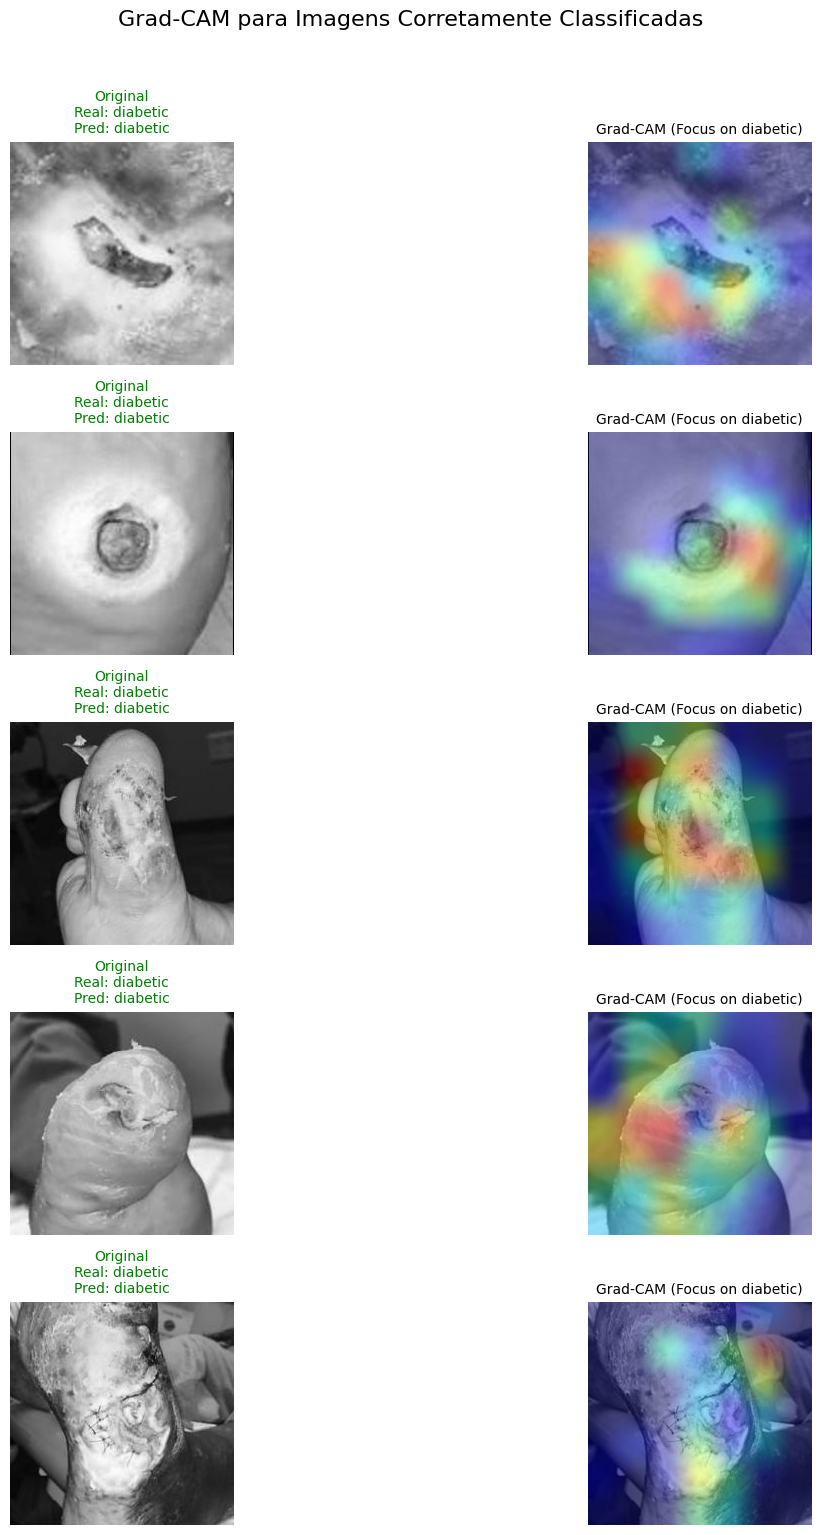

In [115]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import tensorflow as tf

# Assuming df_resultados is available from a previous cell.
# If not, you might need to re-run the cell that creates it (e.g., cell sWsgVWI2w2P3)

# 1. Filter for correctly classified images
df_acertos = df_resultados[df_resultados['real'] == df_resultados['predito']].copy()

if 'df_acertos' in locals() and not df_acertos.empty:
    print(f"Encontrados {len(df_acertos)} acertos para análise Grad-CAM.")
    # Take a random sample of correctly classified images, e.g., 5 images
    num_samples_to_show = min(5, len(df_acertos)) # Show up to 5 correctly classified images
    sample_acertos = df_acertos.sample(num_samples_to_show)

    plt.figure(figsize=(15, num_samples_to_show * 3))
    plt.suptitle("Grad-CAM para Imagens Corretamente Classificadas", fontsize=16, y=1.02)

    for i, (idx, row) in enumerate(sample_acertos.iterrows()):
        relative_img_path = row['arquivo'] # e.g., 'diabetic/129_0.jpg'

        # Need to reconstruct the full path from the test_generator directory
        test_dir_base = "/content/drive/MyDrive/data_split/test"
        full_img_path = os.path.join(test_dir_base, relative_img_path)

        # Load and preprocess the image for the model
        img_raw = tf.keras.preprocessing.image.load_img(full_img_path, target_size=(224, 224))
        img_array = tf.keras.preprocessing.image.img_to_array(img_raw)

        # Apply the same preprocessing function used for training/inference
        img_preprocessed = combined_preprocessing_function(img_array)

        # Get predicted class (the one the model actually predicted)
        predictions = model.predict(np.expand_dims(img_preprocessed, axis=0))
        predicted_class_idx = np.argmax(predictions[0])
        predicted_class_name = class_names[predicted_class_idx]

        # Get actual class name (should be the same as predicted for correct ones)
        true_class_name = row['real']

        # Generate Grad-CAM heatmap
        heatmap = make_gradcam_heatmap(img_preprocessed, model, 'out_relu', pred_index=predicted_class_idx)

        # Display results
        plt.subplot(num_samples_to_show, 2, i * 2 + 1)
        plt.imshow(img_raw) # Show original image
        plt.title(f"Original\nReal: {true_class_name}\nPred: {predicted_class_name}", fontsize=10, color="green")
        plt.axis("off")

        plt.subplot(num_samples_to_show, 2, i * 2 + 2)
        superimposed_img_np = display_gradcam(full_img_path, heatmap)
        plt.imshow(superimposed_img_np)
        plt.title(f"Grad-CAM (Focus on {predicted_class_name})", fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível carregar 'df_acertos' ou o DataFrame está vazio. Verifique se a célula de análise de resultados foi executada e se há acertos.")